# Milestone 4 (alternate) — Weekly and Monthly Forecast Horizons

**Team:** Stephanie Nord, David Jorgensen, Joshua Amaya
**Course project:** predicting hive weight change from colony sensor history

---

## What this notebook is

`Milestone_4.ipynb` predicts **tomorrow's** change in daily-mean hive weight, and its
central result is negative: no single-stage model beats predicting zero, and only a
two-stage classifier→regressor pipeline clears the naive bar, at **+5.9% skill**.

The follow-up: **if we forecast week-to-week or month-to-month instead, what has to change,
and is the answer any better?** A companion, not a replacement — source data, provenance,
publishers' preprocessing and the extreme-event investigation carry over from
`Milestone_4.ipynb` §§2–3 and are not repeated. What *is* repeated is every part of the
protocol the grain change touches, which turns out to be most of it.

**Headline:** at week grain with the target anchored on period mean weight, a
*single-stage* model beats its naive baseline for the first time in this project, and a
two-stage pipeline at the re-derived threshold more than doubles the daily skill score
(+15.2% against +5.9%). §6.2 puts the two side by side.

## How to run

```bash
pip install -r requirements.txt
jupyter nbconvert --to html --execute Milestone_4_alt.ipynb
```

No network, no credentials. Every number and figure is computed at run time from
`data/honey_model.parquet` and `data/honey_weather.parquet`, both committed. Re-grain
logic is in `src/honeymodel/periods.py`, the weather layer in `src/honeymodel/weather.py`.

## The eight things that had to change

| # | What changes | Section | Consequence if skipped |
|---|---|---|---|
| 1 | **The target's anchor** — mean-of-period vs last-day-of-period | 2.3 | Decides whether the model beats its baseline at all |
| 2 | **A coverage gate** — a week from 2 readings is not a week | 2.2 | Target noise scales with how many days happened to report |
| 3 | **Every feature rebuilt** — daily lags are daily constructs | 2.4 | `previous_day_weight_kg` has no meaning at week grain |
| 4 | **An embargo at the split boundary** | 4.1 | Training labels measured inside the test window |
| 5 | **New baselines** — calendar climatology becomes a real competitor | 4.3 | Skill score credits the model for knowing July gains |
| 6 | **A re-derived extreme threshold** — ±5 kg stops meaning extreme | 3.2 | The two-stage pipeline silently models a different thing |
| 7 | **Sample size falls 9× (week) / 42× (month)** | 2.2 | Model capacity and fold count no longer fit the data |
| 8 | **Comparability** — MAE across grains measures different things | 6.2 | Only the skill score can be read across the three horizons |

## Two revisions since first writing

Both come out of `Milestone_5.ipynb`, which carried out §7.3's recommendations: **§5.6 is
new** (the ERA5 weather layer and its ablation ladder), and **§6.1's seasonal table is
corrected**, reversing both of its headline claims.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from honeymodel import data, evaluation as ev, models, periods as pr, weather as wx

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SEED = 42
N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS = 4, 6, 12

# The event-distance columns are normalised on load: the published *_last_dif values are
# in days for 33 hives and seconds for 24, and the period aggregate takes the last value
# in each period, so an un-normalised column would mix units inside one feature.
#
# CORRECTION (Milestone 5): per-hive normalisation is not sufficient. The unit switches
# *within* a hive's record too -- hive 21 advances by 1.0 per day through 2019 and by
# 86,400 per day through mid-2020 -- so these columns remain partly mis-converted. The
# event rungs below are therefore weaker than they look, which reinforces rather than
# changes §5.1's finding that events do not help. Anything that needs event dates
# should use honeymodel.harvest.detect_logged_events, which reads the counter's *reset*
# and needs no unit at all.
daily_df = data.add_season(data.normalise_event_distance_units(data.load_model_table()))

print(f"daily rows : {len(daily_df):,}")
print(f"hives      : {daily_df.hive_id.nunique()}")
print(f"date range : {daily_df.measurement_date.min().date()} to {daily_df.measurement_date.max().date()}")
print(f"weather    : {len(wx.load_weather()):,} site-days across "
      f"{wx.load_weather().site_id.nunique()} sites")

daily rows : 26,215
hives      : 78
date range : 2019-06-25 to 2022-12-30
weather    : 45,594 site-days across 34 sites


## 2. Re-graining the Data

### 2.1 Why the grain is the question, not a parameter

The daily target has a standard deviation of 1.84 kg against a colony mean weight of
34.3 kg, and `Milestone_4.ipynb` §4.3 shows that repeating yesterday's change is the
*worst* of five naive rules (R² −0.58). A series anti-persistent at lag 1 is one where
most of what moves day to day is not colony behaviour.

Three mechanisms make a longer period plausibly easier:

- **Independent day-level noise cancels.** Scale noise, a re-tare, a rain-soaked roof
  drying out — these average toward zero over five to seven days.
- **Beekeeper handling artifacts damp.** The daily milestone §3.5 finds 94% of its
  "extreme events" are the >0.3 kg/min jumps the publishers attribute to handling. A jump
  reversed within the week largely cancels in a period *mean*; one that is not reversed is
  a real mass change.
- **Nectar flow accumulates.** Signal grows roughly linearly with the period, independent
  noise as its square root.

Against that, the row count collapses and seasonal regimes stop being separable by
averaging. The rest of Section 2 makes that cost explicit before Section 5 measures the
benefit.

### 2.2 Aggregation and the coverage waterfall

In [2]:
waterfalls = {grain: pr.coverage_waterfall(daily_df, grain) for grain in ("week", "month")}
for grain, table in waterfalls.items():
    print(f"--- {grain} " + "-" * 52)
    print(table.to_string(index=False))

--- week ----------------------------------------------------
                                   step  rows_remaining  rows_dropped
                    daily rows ingested           26215             0
               aggregated to hive-weeks            4275         21940
     coverage gate (>= 5 observed days)            3510           765
 next period contiguous (target exists)            3012           498
previous period contiguous (lag exists)            2631           381
--- month ----------------------------------------------------
                                   step  rows_remaining  rows_dropped
                    daily rows ingested           26215             0
              aggregated to hive-months            1149         25066
    coverage gate (>= 20 observed days)             814           335
 next period contiguous (target exists)             622           192
previous period contiguous (lag exists)             477           145


Aggregation is not bookkeeping. Two gates fire, each a decision somebody could reasonably
disagree with:

**The coverage gate.** A "week" reconstructed from two observed days is a different
measurement from one reconstructed from seven, and the difference lands directly in the
target. With 23–35% sensor missingness upstream, thin weeks are common. The gate is ≥5
observed days for a week, ≥20 for a month.

**Contiguity, in both directions.** The target is the change over the *next* period, so a
row needs its successor present and adjacent in `period_index`; the lag features need the
predecessor. Contiguity is checked on the period index, not on dates — a hive dark for
three weeks has no valid change across the gap, and interpolating one would fabricate the
most important feature in the model.

The result: **26,215 hive-days become 3,012 usable hive-weeks or 622 hive-months** — a 9×
and 42× reduction, a median of 42 weeks or 10 months per hive. Those counts govern
everything in Section 5, and are why the monthly result carries a caveat the weekly one
does not.

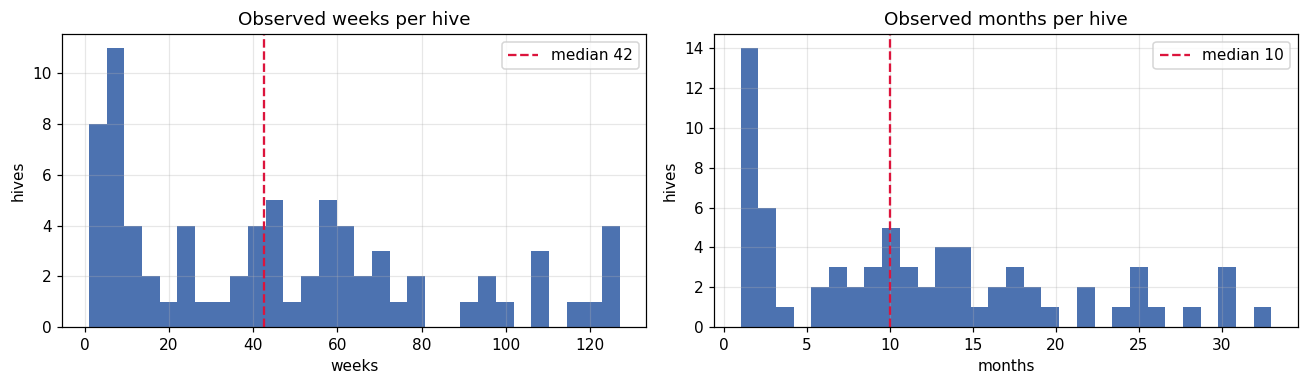

week : 3,510 hive-weeks, median 42 per hive
month: 814 hive-months, median 10 per hive


In [3]:
week_raw = pr.aggregate_to_period(daily_df, "week")
month_raw = pr.aggregate_to_period(daily_df, "month")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (grain, table) in zip(axes, [("week", week_raw), ("month", month_raw)]):
    counts = table.groupby("hive_id").size()
    ax.hist(counts, bins=30, color="#4c72b0", edgecolor="none")
    ax.axvline(counts.median(), color="crimson", linestyle="--",
               label=f"median {int(counts.median())}")
    ax.set(title=f"Observed {grain}s per hive", xlabel=f"{grain}s", ylabel="hives")
    ax.legend()
plt.tight_layout(); plt.show()

print(f"week : {len(week_raw):,} hive-weeks, median {int(week_raw.groupby('hive_id').size().median())} per hive")
print(f"month: {len(month_raw):,} hive-months, median {int(month_raw.groupby('hive_id').size().median())} per hive")

### 2.3 The anchor decision

"How much weight did the hive gain this week" has two defensible readings, and this is the
most consequential choice in the notebook.

| Anchor | Definition | Property |
|---|---|---|
| `last` | change between the **last observed day** of each period | Consecutive changes partition the record exactly and sum to its total change — the property a mass balance should have. But the whole target rests on two single-day readings, so day-level noise and un-reversed handling jumps survive aggregation at full amplitude. |
| `mean` | change between **period mean weights** | Averaging over 5–7 days cancels independent noise and damps a single-day spike to roughly a seventh of its amplitude. Gives up exact additivity: consecutive mean-to-mean changes overlap in what they measure. |

A tiebreaker from the level below: `end_of_day_weight_kg` is itself a *misnomer* — the
publishers compute it as the mean of the day's minute readings, not the last one
(`Milestone_4.ipynb` §2.2), so a period mean keeps the grain change consistent with what
the daily grain already does.

The head-to-head decides it, not the argument:

In [4]:
def prepare(grain, anchor="mean", min_days=None, with_weather=True):
    # Aggregate -> chain features and target -> attach weather -> drop rows with no
    # successor period. The weather join is an equality join on rounded coordinates and
    # date, so it cannot drop or duplicate a row; `lookahead=True` additionally attaches
    # the *forecast* period's weather under next_wx_* names, which §5.6 uses as a
    # labelled upper bound and which the leakage guard blocks by default.
    aggregated = pr.aggregate_to_period(daily_df, grain, min_days=min_days)
    framed = pr.add_period_features(aggregated, anchor=anchor)
    if with_weather:
        framed = wx.add_period_weather(framed, daily_df, period=grain, lookahead=True)
    return framed.dropna(subset=[pr.PERIOD_TARGET]).reset_index(drop=True)


def protocol(frame, feature_set="history", model_name="rf", seed=SEED):
    # One place for the whole protocol: folds -> baselines -> matrix -> per-fold results.
    folds = pr.rolling_origin_period_cv(frame, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS)
    baselines = pr.period_baseline_board(frame, folds)
    matrix = pr.build_period_matrix(frame, feature_set)
    if model_name not in models.NATIVE_NAN_MODELS:  # RF and linear cannot take NaN
        matrix = pr.PeriodMatrix(matrix.X.fillna(matrix.X.median()), matrix.y,
                                 matrix.meta, matrix.frame, matrix.feature_names)
    results = pr.evaluate_period_folds(
        matrix, folds, lambda: models.make_regressor(model_name, seed=seed), model_name, baselines
    )
    return folds, baselines, matrix, results


rows = []
for grain in ("week", "month"):
    for anchor in ("last", "mean"):
        frame = prepare(grain, anchor)
        _, baselines, _, results = protocol(frame)
        rows.append({
            "grain": grain, "anchor": anchor, "n": len(frame),
            "target_sd": frame[pr.PERIOD_TARGET].std(),
            "best_naive": baselines.groupby("model").mae.mean().idxmin(),
            "naive_mae": baselines.groupby("fold").mae.min().mean(),
            "rf_mae": results.mae.mean(),
            "skill_vs_naive": results.skill_vs_naive.mean(),
        })
anchor_table = pd.DataFrame(rows)
display(anchor_table.round(4))

,grain,anchor,n,target_sd,best_naive,naive_mae,rf_mae,skill_vs_naive
0,week,last,3012,4.9554,train_mean,2.2858,2.6989,-0.2361
1,week,mean,3012,4.0950,predict_zero,1.9601,1.7020,0.0866
2,month,last,622,8.8377,predict_zero,5.2503,6.3638,-0.2156
3,month,mean,622,8.0441,month_climatology,4.8622,4.3502,0.0934


**The anchor decides the result.** On the last-day anchor a Random Forest *loses* to the
naive bar at both grains. On the period-mean anchor it wins at both. Same rows, same
features, same folds, same model — the difference is entirely in what "this week's weight"
was taken to mean.

The mean anchor also shrinks the target's sd from 4.96 to 4.10 kg at week grain — not
merely a smoother target, but one with visibly less of the handling-artifact variance.

The rest of this notebook uses `anchor="mean"`.

### 2.4 Features and leakage controls at the new grain

Every daily feature is a daily construct. `previous_day_weight_kg`,
`rolling_3_day_weight_kg`, `weight_slope_2_day_kg` — none mean anything at week grain, and
none survive the re-grain. `periods.py` rebuilds the ladder:

- **Weight chain**: period weight, previous period weight, this and previous period's
  change, 4-period rolling mean and sd of change, deviations from those rollings.
- **Within-period shape** — new, no daily analogue: OLS slope of daily weight across the
  period, sd of daily weight inside it, largest single-day change. A week that gained 2 kg
  steadily and one that gained 2 kg in a jump are different weeks; only these tell them
  apart.
- **Sensors**: mean, sd and max per period rather than a single daily reading, plus
  `foraging_days`, the count of days above 12 °C.
- **Events**: days since each logged beekeeper event, past-facing only.
- **Coverage**: `days_observed` for this period and the last, so the model can see a row
  built from thin data.

The leakage rule is restated at this grain rather than inherited: a shared `FORBIDDEN`
frozenset would have passed every period column through silently, since none of the daily
names exist here.

In [5]:
print(f"{len(pr.PERIOD_FORBIDDEN)} forbidden period columns:")
for column in sorted(pr.PERIOD_FORBIDDEN):
    print(f"  {column}")

# Negative test: asking for a forbidden column must fail, not quietly produce a model.
week_df = prepare("week")
try:
    pr.build_period_matrix(week_df, ["period_weight_kg", pr.PERIOD_TARGET])
    raise SystemExit("LEAKAGE GUARD FAILED -- the target reached a feature matrix")
except pr.PeriodLeakageError as error:
    print(f"\nnegative test passed: {error}")

print(f"\nfeature sets: {list(pr.PERIOD_FEATURE_SETS)}")
print(f"history rung: {len(pr.PERIOD_FEATURE_SETS['history'])} features")

15 forbidden period columns:
  died_next_dif_days
  feeding_next_dif_days
  honey_next_dif_days
  next_period_days_observed
  next_period_index
  next_period_removed_kg
  next_period_start_date
  next_period_weight_kg
  period_extreme_flag
  period_extreme_relative_flag
  queencell_next_dif_days
  swarming_next_dif_days
  target_next_period_gross_gain_kg
  target_next_period_weight_change_kg
  treatment_next_dif_days

negative test passed: these columns are only knowable after the period ends, or are derived from the label, and must not be used as features: ['target_next_period_weight_change_kg']

feature sets: ['history', 'history+sensors', 'history+sensors+events', 'history+sensors+events+hive']
history rung: 19 features


## 3. What the Re-grain Does to the Target

### 3.1 Distribution across the three grains

,grain,n,sd,mae_predict_zero,pct_abs_gt_5kg,5kg_in_sd
0,day,26215,1.841,0.525,1.698,2.717
1,week,3012,4.095,1.962,10.425,1.221
2,month,622,8.044,4.661,29.260,0.622


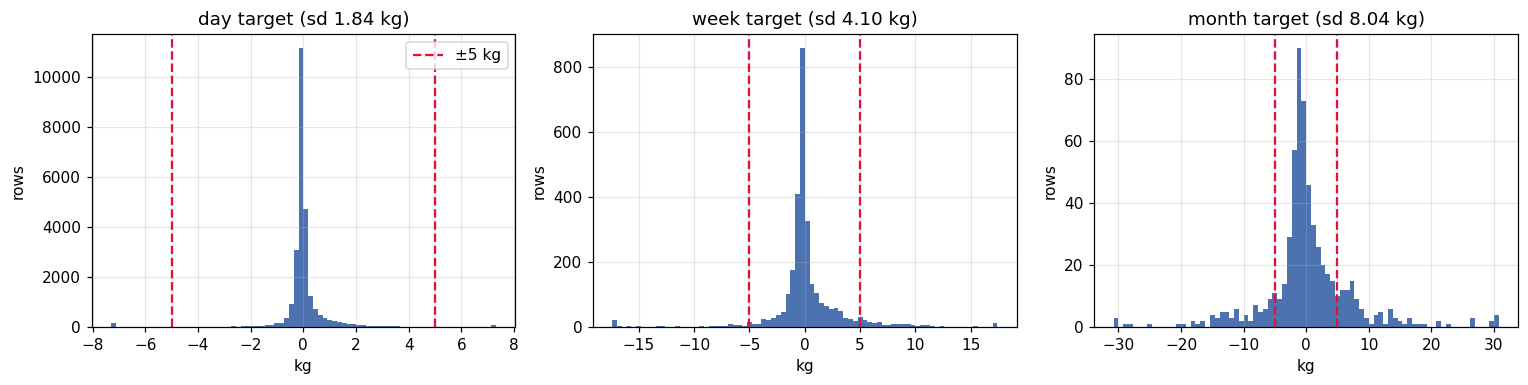

In [6]:
month_df = prepare("month")
targets = {
    "day": daily_df.target_next_day_weight_change_kg.dropna(),
    "week": week_df[pr.PERIOD_TARGET],
    "month": month_df[pr.PERIOD_TARGET],
}

summary = pd.DataFrame([
    {"grain": grain, "n": len(values), "sd": values.std(),
     "mae_predict_zero": values.abs().mean(),
     "pct_abs_gt_5kg": 100 * (values.abs() > 5).mean(),
     "5kg_in_sd": 5 / values.std()}
    for grain, values in targets.items()
])
display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (grain, values) in zip(axes, targets.items()):
    limit = np.percentile(values.abs(), 99)
    ax.hist(values.clip(-limit, limit), bins=80, color="#4c72b0", edgecolor="none")
    for sign in (-1, 1):
        ax.axvline(sign * 5, color="crimson", linestyle="--")
    ax.set(title=f"{grain} target (sd {values.std():.2f} kg)", xlabel="kg", ylabel="rows")
axes[0].legend(["±5 kg"], loc="upper right")
plt.tight_layout(); plt.show()

### 3.2 ±5 kg stops meaning "extreme"

The daily milestone splits the target at ±5 kg (1.7% positive rate) and builds its
two-stage pipeline around that split. The threshold was inherited by convention; its §3.6
sweeps it and finds the trade-off mild.

Carrying it across the grain change is not mild. Five kilograms is 2.7 daily sd but only
1.2 weekly ones, so the same number now selects **10.4% of weeks** — no longer a tail, and
no longer the thing the two-stage architecture was designed around.

In [7]:
sweep = pr.period_threshold_sweep(week_df, [3, 5, 7, 10, 11.1, 13.5, 20])
display(sweep)

WEEK_THRESHOLD = round(pr.relative_extreme_threshold(week_df[pr.PERIOD_TARGET]), 1)
daily_rate = 100 * (targets["day"].abs() > 5).mean()
print(f"daily rule: 5.0 kg = 2.7 daily sd  -> {daily_rate:.2f}% of hive-days extreme")
print(f"same 5.0 kg at week grain          -> {100 * (week_df[pr.PERIOD_TARGET].abs() > 5).mean():.2f}% of hive-weeks")
print(f"re-derived at 2.7 weekly sd        -> {WEEK_THRESHOLD} kg")

,threshold_kg,n_extreme,positive_rate_pct,threshold_in_sd
0,3.0,542,17.99,0.73
1,5.0,314,10.42,1.22
2,7.0,199,6.61,1.71
3,10.0,111,3.69,2.44
4,11.1,91,3.02,2.71
5,13.5,63,2.09,3.30
6,20.0,22,0.73,4.88


daily rule: 5.0 kg = 2.7 daily sd  -> 1.70% of hive-days extreme
same 5.0 kg at week grain          -> 10.42% of hive-weeks
re-derived at 2.7 weekly sd        -> 11.1 kg


**The threshold is re-derived in standard-deviation units, not carried over in kilograms.**
At 2.7 weekly sd it lands at **11.1 kg**, selecting 3.0% of weeks. §5.3 uses this
figure.

Matching the sd multiple does *not* reproduce the daily 1.7% positive rate — it gives
3.0%, and 1.7% would need 13.5 kg (3.3 sd). Only one can be held fixed, and the discrepancy
is itself a measurement: the same sd multiple captures more of the weekly distribution, so
the weekly target is **less heavy-tailed relative to its own spread**. That is what
aggregation should do, and it corroborates §2.1's mechanism from the sweep rather than the
anchor comparison. The sd multiple carries across because it means the same thing at both
grains.

An absolute threshold remains the wrong shape at any grain: 11 kg on a 10 kg nucleus and
11 kg on a 100 kg production hive are not the same event, and these hives span 0–111.7 kg.
A per-hive relative rule is the honest fix, left as future work as in the daily milestone.

## 4. Validation Framework

### 4.1 The embargo — the one genuinely new correctness requirement

The daily splitter is safe for a reason that stops being true here. A daily row's label
lands one day later, so cutting training at the origin date leaves at most one day of
overlap, and `assert_split_integrity` catches it.

At week grain a row's label is measured over the **following period** — up to 7 days after
its features — so a training row whose features predate the origin can carry a label
measured *inside the test window*. The daily rule here trains on the test set, and the
daily assertion, comparing feature dates, passes it.

`rolling_origin_period_cv` therefore states the rule on the label: a training row is
admitted only when its `target_period_end_date` falls strictly before the first test
observation. `embargo=False` reproduces the unsafe rule so its cost can be measured rather
than asserted.

In [8]:
embargo_rows = []
for embargo in (True, False):
    folds = pr.rolling_origin_period_cv(week_df, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS,
                                        embargo=embargo)
    baselines = pr.period_baseline_board(week_df, folds)
    matrix = pr.build_period_matrix(week_df, "history")
    matrix = pr.PeriodMatrix(matrix.X.fillna(matrix.X.median()), matrix.y, matrix.meta,
                             matrix.frame, matrix.feature_names)
    results = pr.evaluate_period_folds(
        matrix, folds, lambda: models.make_regressor("rf", seed=SEED), "rf", baselines
    )
    embargo_rows.append({
        "embargo": embargo,
        "train_rows": sum(len(fold.train_index) for fold in folds),
        "rows_embargoed": sum(fold.extra["embargoed_rows"] for fold in folds),
        "mae": results.mae.mean(),
        "skill_vs_naive": results.skill_vs_naive.mean(),
    })
display(pd.DataFrame(embargo_rows).round(4))

# The daily assertion compares feature dates and passes the unsafe split; the period
# assertion compares label dates and rejects it.
unsafe = pr.rolling_origin_period_cv(week_df, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS,
                                     embargo=False)
try:
    pr.assert_period_split_integrity(week_df, unsafe[0])
    print("\nno overlap detected in fold 1 without the embargo")
except AssertionError as error:
    print(f"\nperiod assertion rejects the un-embargoed split: {error}")

,embargo,train_rows,rows_embargoed,mae,skill_vs_naive
0,True,5281,100,1.7020,0.0866
1,False,5381,0,1.7471,0.0395



period assertion rejects the un-embargoed split: fold_1_2020-07-22: a training label ends 2020-08-02 but the test window opens 2020-07-22 -- the label was measured inside the test period


The embargo removes **100 of 5,381 training rows (1.9%)**, and — as measured, not as hoped
— the un-embargoed split does not score *better*; its MAE is slightly worse. On this
dataset the overlapping rows are noise rather than an oracle.

That does not say the embargo is unnecessary. Whether contamination inflates a score
depends on how much signal the overlapping rows carry, which varies by dataset, model and
fold; here they are few and the target is noisy, so the contamination has nothing to give.
The embargo is a correctness property, not a performance optimisation, and a protocol that
holds only when the leak happens to be harmless is not a protocol. It stays on.

### 4.2 Rolling-origin folds at period grain

In [9]:
folds, baselines, matrix, _ = protocol(week_df)
display(pd.DataFrame([fold.describe() for fold in folds]))

for fold in folds:
    pr.assert_period_split_integrity(week_df, fold)
print("split integrity: every fold's training labels were measured strictly before its "
      "test window opens")

month_folds, month_baselines, month_matrix, _ = protocol(month_df)
print(f"\nmonthly folds carry {[len(f.test_index) for f in month_folds]} test rows "
      f"and {[len(f.train_index) for f in month_folds]} training rows")

,fold,n_train,n_test,train_end,test_start,test_end,embargoed_rows
0,fold_1_2020-07-22,423,689,2020-07-19,2020-07-22,2021-01-11,57
1,fold_2_2021-01-22,1169,419,2021-01-24,2021-02-23,2021-07-20,0
2,fold_3_2021-07-22,1566,556,2021-07-25,2021-07-26,2022-01-17,22
3,fold_4_2022-01-22,2123,433,2022-01-23,2022-01-24,2022-07-20,21


split integrity: every fold's training labels were measured strictly before its test window opens



monthly folds carry [130, 96, 123, 84] test rows and [86, 245, 319, 445] training rows


Four expanding-window folds, six-month horizons, matching the daily protocol so the two are
comparable. The monthly folds are the warning sign: 84–130 test rows against a 41-feature
matrix, so every monthly number in §5.2 is a small-sample estimate and labelled as one.

### 4.3 Baselines have to be re-set

Predicting zero is a strong competitor at daily grain because the target's mean is
0.002 kg, and it weakens as the period lengthens and seasonal drift accumulates. In the
same move, **calendar climatology gets much stronger** — over a month, "what does a hive
in Germany usually do in July" is most of the answer. Scoring against predict-zero alone
would let a model post a large skill score for learning only that July gains and November
loses. `period_baselines` adds `month_climatology` and `hive_month_climatology`, and the
skill denominator is the best of all six.

In [10]:
board = pd.concat([
    ev.fold_summary(baselines).assign(grain="week"),
    ev.fold_summary(month_baselines).assign(grain="month"),
])
display(board[["grain", "model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "n"]].round(3))

for grain, frame in (("week", baselines), ("month", month_baselines)):
    best = frame.groupby("model").mae.mean().idxmin()
    print(f"{grain:>5}: best naive = {best} at MAE {frame.groupby('fold').mae.min().mean():.3f} kg")

,grain,model,mae_mean,mae_sd,rmse_mean,r2_mean,n
0,week,predict_zero,1.979,0.919,3.852,-0.019,2097
1,week,train_mean,1.991,0.905,3.858,-0.021,2097
2,week,month_climatology,2.204,1.070,3.878,-0.034,2097
3,week,persistence,2.308,0.644,4.673,-0.799,2097
4,week,hive_mean,2.314,0.706,4.129,-0.256,2097
5,week,hive_month_climatology,2.385,1.191,4.175,-0.171,2097
0,month,month_climatology,5.168,2.788,7.563,0.019,433
1,month,predict_zero,5.252,3.400,8.177,-0.022,433
2,month,train_mean,5.303,3.479,8.217,-0.029,433
3,month,hive_month_climatology,5.707,3.258,8.361,-0.193,433


 week: best naive = predict_zero at MAE 1.960 kg
month: best naive = month_climatology at MAE 4.862 kg


**The bar moves, and at month grain it moves to a different rule.** Weekly, predicting
zero still wins (MAE 1.98). Monthly, `month_climatology` takes over (MAE 5.17 against
predict-zero's 5.25) — the crossover predicted above, arriving where the seasonal signal
starts to dominate the period.

Persistence remains the worst rule at both grains (weekly R² −0.80, monthly −1.55). The
lag-1 anti-persistence the daily milestone found is not a daily artifact: it survives
aggregation, so it is a property of the colony weight series itself.

## 5. Models

Same protocol as the daily milestone: every model on the same rolling-origin folds,
reporting **skill score** — percentage reduction in MAE against that fold's best naive
predictor.

### 5.1 The weekly model board

In [11]:
EXPERIMENTS = [
    ("history / RF",                         "history",                     "rf"),
    ("history+sensors / RF",                 "history+sensors",             "rf"),
    ("history+sensors+events / RF",          "history+sensors+events",      "rf"),
    ("history+sensors+events+hive / RF",     "history+sensors+events+hive", "rf"),
    ("history / HistGB",                     "history",                     "hist_gb"),
    ("history+sensors / HistGB",             "history+sensors",             "hist_gb"),
    ("history+sensors+events / HistGB",      "history+sensors+events",      "hist_gb"),
    ("history+sensors / linear",             "history+sensors",             "linear"),
]


def model_board(frame, folds, baselines):
    results = []
    for label, feature_set, model_name in EXPERIMENTS:
        built = pr.build_period_matrix(frame, feature_set)
        if model_name not in models.NATIVE_NAN_MODELS:
            built = pr.PeriodMatrix(built.X.fillna(built.X.median()), built.y, built.meta,
                                    built.frame, built.feature_names)
        results.append(pr.evaluate_period_folds(
            built, folds, lambda name=model_name: models.make_regressor(name, seed=SEED),
            label, baselines,
        ))
    return pd.concat(results, ignore_index=True)


week_board = model_board(week_df, folds, baselines)
display(ev.fold_summary(week_board)[
    ["model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "skill_mean", "skill_sd"]
].round(4))

,model,mae_mean,mae_sd,rmse_mean,r2_mean,skill_mean,skill_sd
0,history / RF,1.7020,0.5643,3.2978,0.1445,0.0866,0.1618
1,history+sensors / RF,1.7142,0.5691,3.2751,0.1745,0.0818,0.1464
2,history+sensors+events / RF,1.7451,0.5444,3.2951,0.1614,0.0597,0.1505
3,history+sensors+events+hive / RF,1.7680,0.5878,3.2252,0.2175,0.0555,0.1256
4,history / HistGB,1.8227,0.5453,3.3772,0.1213,0.0123,0.1897
5,history+sensors / linear,1.8668,0.5903,3.3547,0.1133,-0.0156,0.2486
6,history+sensors / HistGB,1.8775,0.5811,3.4585,0.0971,-0.0172,0.2127
7,history+sensors+events / HistGB,1.8888,0.5489,3.4348,0.1054,-0.0293,0.2168


**A single-stage model beats the naive bar for the first time in this project.** Random
Forest on history features alone reaches MAE 1.702 against a naive 1.960 — **+8.7% skill**,
R² 0.145. The daily milestone's best single-stage result was −6%.

Three secondary readings, each inverting something from the daily work:

- **Sensors, events and hive context all hurt.** `history` is the best rung; sensor
  aggregates cost 0.5% skill and event distances 2.7%, where at daily grain sensors were a
  small gain. Likely capacity: 3,012 rows across 19 features is already thin, and the
  sensor rung takes it to 35.
- **Random Forest now beats boosting**, reversing the daily §5.5 finding by a wide margin
  (1.70 vs 1.82). §5.4 checks whether that is inside the seed noise.
- **Linear regression is competitive** (1.87, within noise of HistGB), where at daily grain
  it was not. A smoothed weekly target has more linear structure to find.

### 5.2 The monthly board — and why it is reported with a caveat

In [12]:
month_board = model_board(month_df, month_folds, month_baselines)
display(ev.fold_summary(month_board)[
    ["model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "skill_mean", "skill_sd", "n"]
].round(4))
print(f"monthly test rows in total: {len(month_df.iloc[np.concatenate([f.test_index for f in month_folds])]):,}")

,model,mae_mean,mae_sd,rmse_mean,r2_mean,skill_mean,skill_sd,n
0,history+sensors+events+hive / RF,4.3130,2.6176,6.6357,0.2812,0.1229,0.0250,433
1,history / RF,4.3502,2.4301,6.6686,0.2473,0.0934,0.0290,433
2,history+sensors+events / RF,4.4309,2.5704,6.8584,0.2173,0.0872,0.0085,433
3,history+sensors / RF,4.4463,2.5957,6.8671,0.2218,0.0861,0.0085,433
4,history+sensors+events / HistGB,4.6464,1.9876,7.1549,0.0491,-0.0574,0.2923,433
5,history / HistGB,4.6751,1.9539,7.0394,0.0512,-0.0588,0.2335,433
6,history+sensors / HistGB,4.6943,2.0134,7.1739,0.0473,-0.0662,0.2836,433
7,history+sensors / linear,5.4326,1.6314,7.9490,-0.5358,-0.3432,0.5821,433


monthly test rows in total: 433


Monthly Random Forest on the full feature rung reaches **+12.3% skill (sd 2.5%)** with
R² 0.281 — nominally the notebook's best score, and remarkably consistent across folds.
Every RF rung clears +8.6%; every HistGB rung is negative.

Two things differ from the weekly board and neither should be over-read: sensors, events
and hive context *help* here where they hurt at week grain, and the fold-to-fold skill sd
is a quarter of the weekly figure. Both are what a smaller, more strongly seasonal sample
tends to produce — with 8 rows per hive the model has little to do but learn the seasonal
curve, and every fold agrees about that curve.

It rests on **622 rows, 433 of them ever scored, across four folds averaging 108 test rows
each** — roughly six observations per feature at 19 features, and the full rung uses 40.
The small sd is not the reassurance it looks like: four folds from 3.5 years of one
country's weather are not four independent samples of "a year". Monthly is *promising and
underpowered*; weekly is the grain this dataset can support.

### 5.3 Three framings, with the threshold re-derived

The daily milestone's central table compares an oracle-gated routine model (upper bound
only — its test rows are selected using the label) against a deployable two-stage pipeline.
The same comparison at week grain, with the threshold re-derived to 11.1 kg per §3.2 rather
than carried over at 5 kg:

In [13]:
framing_rows = []
for fold in folds:
    X_train, y_train = matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
    X_test, y_test = matrix.X.iloc[fold.test_index], matrix.y.iloc[fold.test_index]
    bar = float(baselines[baselines.fold == fold.name].mae.min())

    single = models.make_regressor("rf", seed=SEED).fit(X_train, y_train)
    candidates = {
        ("single-stage RF", "deployable"): single.predict(X_test),
    }
    for blend, label in ((False, "two-stage, hard gate"), (True, "two-stage, blended")):
        two_stage = models.TwoStageModel(
            regressor="rf", threshold_kg=WEEK_THRESHOLD, blend=blend, seed=SEED
        ).fit(X_train, y_train)
        candidates[(label, "deployable")] = two_stage.predict(X_test)

    for (name, honesty), prediction in candidates.items():
        metrics = ev.regression_metrics(y_test, prediction)
        framing_rows.append({"framing": name, "honest_label": honesty, "fold": fold.name,
                             **metrics, "skill_vs_naive": ev.skill_score(metrics["mae"], bar)})

    # Milestone 3's framing, reproduced only so it can be labelled: routine rows are
    # selected using the label, so this is an upper bound and not a deployable number.
    y_oracle, p_oracle = models.oracle_gated_predict(single, X_test, y_test, WEEK_THRESHOLD)
    metrics = ev.regression_metrics(y_oracle, p_oracle)
    framing_rows.append({"framing": "routine only, oracle-gated", "honest_label": "UPPER BOUND",
                         "fold": fold.name, **metrics,
                         "skill_vs_naive": ev.skill_score(metrics["mae"], bar)})

framings = pd.DataFrame(framing_rows)
display(framings.groupby(["framing", "honest_label"])[["mae", "rmse", "r2", "skill_vs_naive"]]
        .mean().round(4).reset_index().sort_values("mae"))

,framing,honest_label,mae,rmse,r2,skill_vs_naive
0,"routine only, oracle-gated",UPPER BOUND,1.4261,2.4547,-0.0219,0.2126
3,"two-stage, hard gate",deployable,1.6296,3.2912,0.2208,0.1516
2,"two-stage, blended",deployable,1.6327,3.2407,0.2367,0.1479
1,single-stage RF,deployable,1.7020,3.2978,0.1445,0.0866


In [14]:
classifier_rows = []
for fold in folds:
    y_train = matrix.y.iloc[fold.train_index]
    y_test = matrix.y.iloc[fold.test_index]
    classifier = models.make_classifier("rf", seed=SEED).fit(
        matrix.X.iloc[fold.train_index], (y_train.abs() > WEEK_THRESHOLD).to_numpy()
    )
    probability = classifier.predict_proba(matrix.X.iloc[fold.test_index])[:, 1]
    classifier_rows.append({"fold": fold.name, **models.classifier_report(
        (y_test.abs() > WEEK_THRESHOLD).to_numpy(), probability)})

classifier_board = pd.DataFrame(classifier_rows)
display(classifier_board.round(4))
print(f"mean PR-AUC {classifier_board.pr_auc.mean():.3f} against a no-skill rate of "
      f"{classifier_board.pr_auc_no_skill.mean():.3f}  ->  {classifier_board.pr_auc_lift.mean():.1f}x lift")

,fold,pr_auc,roc_auc,positive_rate,pr_auc_no_skill,pr_auc_lift
0,fold_1_2020-07-22,0.3657,0.8454,0.0087,0.0087,41.9902
1,fold_2_2021-01-22,0.4387,0.9360,0.0382,0.0382,11.4883
2,fold_3_2021-07-22,0.2293,0.8731,0.0090,0.0090,25.4979
3,fold_4_2022-01-22,0.2803,0.8268,0.0554,0.0554,5.0569


mean PR-AUC 0.328 against a no-skill rate of 0.028  ->  21.0x lift


**The two-stage pipeline is worth more at week grain than at day grain.** The hard-gated
version reaches MAE 1.630 and **+15.2% skill**, against the daily milestone's +5.9%. The
blended variant is indistinguishable (+14.8%), itself informative — at daily grain the
blend was clearly better because a 30%-confident extreme day contributed proportionally;
at week grain the classifier is confident enough that hard routing costs nothing.

The gap between the oracle-gated framing and the deployable two-stage number is much
narrower here than at daily grain (0.315 against 0.479 MAE). That gap is the price of not
knowing in advance whether next week is extreme, and a stronger classifier shrinks it.

The classifier is stronger: **PR-AUC 0.23–0.44 against a no-skill rate of 0.009–0.055**.
Lift spans 5–42× only because the positive rate varies fivefold across folds — fold 4 is a
spring-summer window with 5.5% extreme weeks, fold 3 a summer-winter one with 0.9%. Lift
is the wrong summary when the base rate moves that much; read PR-AUC against the fold's
own no-skill rate.

### 5.4 Stability, and generalisation to unseen hives

In [15]:
stability_rows = []
for model_name in ("rf", "hist_gb"):
    built = pr.build_period_matrix(week_df, "history")
    if model_name not in models.NATIVE_NAN_MODELS:
        built = pr.PeriodMatrix(built.X.fillna(built.X.median()), built.y, built.meta,
                                built.frame, built.feature_names)
    for seed in (0, 1, 2, 3, 4):
        result = pr.evaluate_period_folds(
            built, folds, lambda name=model_name, s=seed: models.make_regressor(name, seed=s),
            model_name, baselines,
        )
        stability_rows.append({"model": model_name, "seed": seed,
                               "mae": result.mae.mean(), "r2": result.r2.mean()})
stability = pd.DataFrame(stability_rows)
display(stability.round(4))

rf_seeds = stability[stability.model == "rf"]
hgb_seeds = stability[stability.model == "hist_gb"]
print(f"RF     MAE range: {rf_seeds.mae.min():.4f} - {rf_seeds.mae.max():.4f}")
print(f"HistGB MAE range: {hgb_seeds.mae.min():.4f} - {hgb_seeds.mae.max():.4f}")
print(f"non-overlapping ranges: {ev.ranking_is_significant(rf_seeds, hgb_seeds)}")

hive_folds = ev.grouped_hive_cv(week_df, n_folds=5, seed=SEED)
hive_results = pr.evaluate_period_folds(
    matrix, hive_folds, lambda: models.make_regressor("rf", seed=SEED), "rf"
)
display(hive_results.round(4))
print(f"leave-hives-out MAE {hive_results.mae.mean():.3f} +/- {hive_results.mae.std():.3f}, "
      f"R2 {hive_results.r2.mean():.3f} +/- {hive_results.r2.std():.3f}")

,model,seed,mae,r2
0,rf,0,1.7144,0.1407
1,rf,1,1.7174,0.1376
2,rf,2,1.7207,0.1412
3,rf,3,1.7259,0.1319
4,rf,4,1.7107,0.1472
5,hist_gb,0,1.8227,0.1213
6,hist_gb,1,1.8227,0.1213
7,hist_gb,2,1.8227,0.1213
8,hist_gb,3,1.8227,0.1213
9,hist_gb,4,1.8227,0.1213


RF     MAE range: 1.7107 - 1.7259
HistGB MAE range: 1.8227 - 1.8227
non-overlapping ranges: True


,fold,model,mae,rmse,r2,bias,n
0,hives_1,rf,1.7996,3.9057,0.3613,0.0442,586
1,hives_2,rf,1.5352,2.7229,0.3954,-0.0205,454
2,hives_3,rf,1.5209,2.9646,0.3530,0.1229,750
3,hives_4,rf,1.6709,3.4839,0.3600,-0.1056,446
4,hives_5,rf,1.5138,3.0681,0.4023,-0.0139,776


leave-hives-out MAE 1.608 +/- 0.125, R2 0.374 +/- 0.023


The RF / HistGB ranking survives across seeds — the MAE ranges do not overlap — so **the
reversal against the daily §5.5 finding is real, not seed noise.** Boosting wins at daily
grain, the forest at week grain. Plausible reason is sample size: HistGradientBoosting's
defaults are tuned for tens of thousands of rows and it is being handed 2,000.

Leave-hives-out gives **MAE 1.608 ± 0.125 and R² 0.374 ± 0.023 — better than the temporal
folds**, as the daily milestone also found. The model is not leaning on hive identity, and
an uninstrumented hive is not a harder case than a future week of a known one. For
deployment that is the result that matters.

Leave-hives-out has no temporal separation by construction: it answers "does this transfer
to a new colony", not "does this transfer to next year". Two questions, two folds.

### 5.5 What the model is actually using

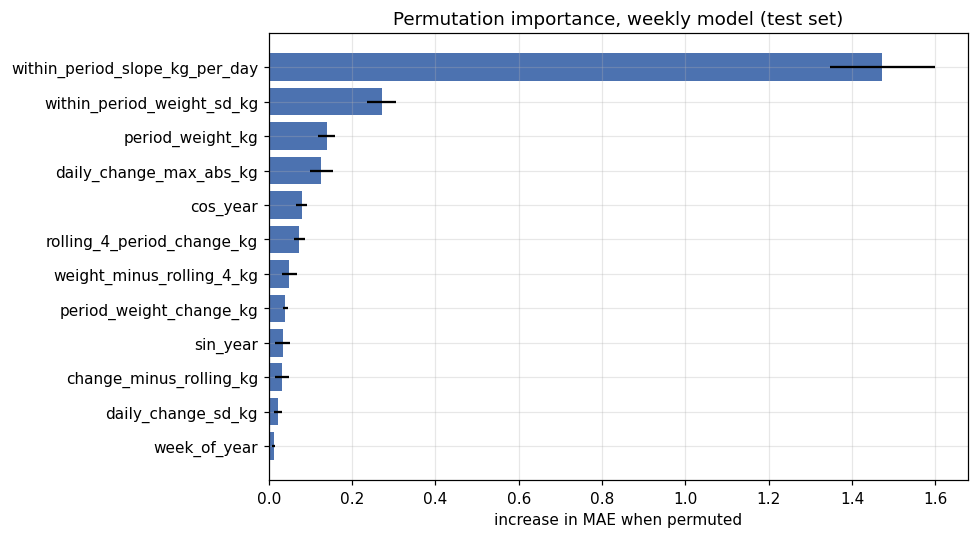

,feature,importance_mean,importance_sd
0,within_period_slope_kg_per_day,1.47258,0.12582
1,within_period_weight_sd_kg,0.27071,0.03460
2,period_weight_kg,0.13886,0.01979
3,daily_change_max_abs_kg,0.12562,0.02744
4,cos_year,0.07861,0.01284
5,rolling_4_period_change_kg,0.07352,0.01347
6,weight_minus_rolling_4_kg,0.04938,0.01821
7,period_weight_change_kg,0.03985,0.00658
8,sin_year,0.03361,0.01827
9,change_minus_rolling_kg,0.03191,0.01638


In [16]:
last_fold = folds[-1]
winner = models.make_regressor("rf", seed=SEED).fit(
    matrix.X.iloc[last_fold.train_index], matrix.y.iloc[last_fold.train_index]
)
importance = models.permutation_feature_importance(
    winner, matrix.X.iloc[last_fold.test_index], matrix.y.iloc[last_fold.test_index], n_repeats=10
).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance.feature[::-1], importance.importance_mean[::-1],
        xerr=importance.importance_sd[::-1], color="#4c72b0")
ax.set(xlabel="increase in MAE when permuted",
       title="Permutation importance, weekly model (test set)")
plt.tight_layout(); plt.show()
display(importance.round(5))

**The dominant feature has no daily analogue.** `within_period_slope_kg_per_day` — the OLS
trend of daily weight across the current week — is worth roughly 5× the next feature, where
the daily model's dominant feature was yesterday's change.

The distinction is mechanical: yesterday's change is one noisy difference, while the
within-week slope is a least-squares trend through 5–7 readings, estimating the same
quantity — the colony's current rate of mass change — with far less variance. Next are
`within_period_weight_sd_kg` and `daily_change_max_abs_kg`, both measures of *how erratic*
the week was rather than how much it gained.

So the model is using the shape of the week, visible only because the daily rows were
summarised rather than averaged away — an aggregation producing period means alone would
have discarded the best predictor in the table.

The daily milestone's collinearity caveat applies unchanged: permutation importance
understates every member of a correlated group, and the weight chain is correlated by
construction.

### 5.6 Weather

Every feature above is a function of the hive's own past weight, so the model can only
extrapolate a trend — nothing tells it next week is forecast to rain for five days. That is
the largest missing input in the project, and the one with the clearest mechanism: a colony
gains mass when bees fly, and bees fly when it is warm, dry and bright.

`data/honey_weather.parquet` fills it — 45,594 site-days of ERA5 reanalysis from the
Open-Meteo Historical Weather API, one series per distinct hive site, no missing days.
Reanalysis rather than the GHCN-Daily station records the Milestone 4 plan named first:
34 sites across six degrees of longitude would each need a nearest-station search, a
distance threshold and a gap-filling rule, and a gridded product removes all three. The
cost is modelled values on a ~9 km grid rather than measurements.
`scripts/pull_weather_snapshot.py` is the project's only network call; it has been run and
its output is committed.

The ladder below separates two things:

- **`+weather_core` / `+weather`** carry the weather of the week being *forecast from*, all
  knowable on Sunday evening. Deployable.
- **`+lookahead`** additionally carries the weather of the week being *forecast* — the
  ceiling a perfect seven-day forecast would reach, not a result. Labelled `UPPER BOUND`
  below, and `weather.WEATHER_LOOKAHEAD_FEATURES` is registered with
  `periods.assert_no_period_leakage`, so a matrix built from it raises `PeriodLeakageError`
  unless the caller passes `allow=` and takes the label with it.

`weather_core` is five features, one per mechanism — radiation, rain, degree-days,
foraging days, wind. The full set is sixteen, and the result below is largely about the
difference between those two numbers rather than about weather.

In [17]:
WEATHER_LADDER = wx.weather_feature_sets("history")
ALLOW = set(wx.WEATHER_LOOKAHEAD_FEATURES)

weather_rows = []
for rung, names in WEATHER_LADDER.items():
    is_upper_bound = any(name.startswith("next_wx_") for name in names)
    built = pr.build_period_matrix(week_df, names, allow=ALLOW if is_upper_bound else None)
    built = pr.PeriodMatrix(built.X.fillna(built.X.median()), built.y, built.meta,
                            built.frame, built.feature_names)
    weather_rows.append(pr.evaluate_period_folds(
        built, folds, lambda: models.make_regressor("rf", seed=SEED), rung, baselines,
    ).assign(n_features=len(names),
             honest_label="UPPER BOUND" if is_upper_bound else "deployable"))
weather_board = pd.concat(weather_rows, ignore_index=True)

order = list(WEATHER_LADDER)
per_fold = weather_board.pivot(index="fold", columns="model", values="skill_vs_naive")[order]
display((100 * per_fold).round(1))

display(pd.DataFrame({
    "n_features": weather_board.groupby("model").n_features.first(),
    "label": weather_board.groupby("model").honest_label.first(),
    "skill_all_folds_pct": 100 * weather_board.groupby("model").skill_vs_naive.mean(),
    "skill_folds_2_4_pct": 100 * per_fold.iloc[1:].mean(),
    "skill_sd_pct": 100 * weather_board.groupby("model").skill_vs_naive.std(),
}).loc[order].round(2))

model,history,history+weather_core,history+weather,history+weather_core+lookahead,history+weather+lookahead,weather-only
fold,,,,,,
fold_1_2020-07-22,-14.3,-17.4,-50.4,-17.2,-57.9,-88.7
fold_2_2021-01-22,19.3,19.2,18.5,21.1,20.4,-33.0
fold_3_2021-07-22,8.9,11.2,8.2,13.0,12.4,-11.5
fold_4_2022-01-22,20.8,19.2,18.6,19.5,21.0,-13.0


,n_features,label,skill_all_folds_pct,skill_folds_2_4_pct,skill_sd_pct
model,,,,,
history,19,deployable,8.66,16.30,16.18
history+weather_core,24,deployable,8.03,16.52,17.37
history+weather,35,deployable,-1.29,15.08,33.11
history+weather_core+lookahead,29,UPPER BOUND,9.11,17.87,17.87
history+weather+lookahead,51,UPPER BOUND,-1.02,17.95,38.14
weather-only,19,deployable,-36.55,-19.16,36.13


In [18]:
# The guard is not decorative: building the look-ahead rung without `allow=` fails.
try:
    pr.build_period_matrix(week_df, WEATHER_LADDER["history+weather_core+lookahead"])
    print("NO GUARD — this should not print")
except pr.PeriodLeakageError as error:
    print("PeriodLeakageError raised as designed:\n ", str(error)[:200], "...")

PeriodLeakageError raised as designed:
  these columns are only knowable after the period ends, or are derived from the label, and must not be used as features: ['next_wx_growing_degree_days_10c_sum', 'next_wx_is_foraging_day_sum', 'next_wx_ ...


**Weather you already have is worth nothing, and a perfect forecast is worth about half a
point.**

| Rung | Features | Skill | Label |
|---|---|---|---|
| `history` | 19 | **+8.7%** | deployable |
| `history+weather_core` | 24 | +8.0% | deployable |
| `history+weather_core+lookahead` | 29 | **+9.1%** | **UPPER BOUND** |
| `history+weather` | 35 | −1.3% | deployable |
| `history+weather+lookahead` | 51 | −1.0% | **UPPER BOUND** |
| `weather-only` | 19 | −36.6% | deployable |

Three readings, and only the second is a gain.

**Current-week weather adds nothing.** +8.0% against +8.7% for no weather at all — inside
a fold-to-fold sd of 17 points, so "no effect" rather than "a small loss". Unsurprising on
reflection: the weight series *is* an instrument for the weather that just happened, and
`within_period_slope_kg_per_day` has already read it.

**A perfect forecast is worth +0.45 points, and that is the ceiling.** The look-ahead rung
reaches +9.1%, and on folds 2–4 alone +17.9% against +16.3%. A real seven-day forecast is
not perfect and degrades across the week, so the deployable value is a fraction of half a
point on a base of 8.7. **This decides whether the weather integration is worth building,
and it says no.**

**Sixteen weather features do not fit in 3,012 rows.** The full rung drops to −1.3%, and
the whole loss is fold 1 (−14.3% → −50.4%) while folds 2–4 barely move. Fold 1 is the
first expanding-window origin and trains on barely a year — a dimensionality result, not a
weather result, and why the five-feature rung chosen before the board was run is the honest
way to ask the question.

`weather-only` — weather plus seasonality terms, nothing about the hive — scores −36.6%.
Whatever this model knows, it does not learn it from the sky.

## 6. Results and Interpretation

### 6.1 Where the weekly model works and where it fails

Metrics pooled across all four folds' out-of-sample predictions, so every season is
represented — the last fold alone covers January to July and contains 22 summer weeks.

**The denominator is the decision here, and the first version of this notebook got it
wrong.** Skill is a ratio, and scoring every season against *one* fold-wide naive bar is
not neutral when the target's variance is this seasonal: the annual bar carries summer's
variance into the winter comparison and winter's into the summer one. Both columns are
below — `skill_vs_naive` uses the best naive rule *within* each segment,
`skill_vs_pooled_naive` the single-bar convention originally published, kept so the size of
the difference is visible rather than asserted.

**Neither is universally right.** Which to read depends on whether the segment is knowable
before the forecast is made. A season is — a beekeeper choosing between this model and a
rule of thumb in January is choosing *in January*. A |change| decile is not: defined by the
label, so a within-decile bar is a competitor that already knows the answer. Hence the
within-segment column for seasons, the pooled column for deciles.

In [19]:
out_of_fold = []
oof_baselines = {}
for fold in folds:
    model = models.make_regressor("rf", seed=SEED).fit(
        matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
    )
    block = matrix.meta.iloc[fold.test_index].copy()
    block["y_true"] = matrix.y.iloc[fold.test_index].to_numpy()
    block["y_pred"] = model.predict(matrix.X.iloc[fold.test_index])
    block["fold"] = fold.name
    out_of_fold.append(block)
    # The naive rules' predictions for the same rows, so each segment can be scored
    # against the best naive *within* it rather than against an annual average.
    for name, values in pr.period_baselines(matrix.frame, fold).items():
        oof_baselines.setdefault(name, []).append(values)
out_of_fold = pd.concat(out_of_fold, ignore_index=True)
oof_baselines = {name: np.concatenate(blocks) for name, blocks in oof_baselines.items()}

pooled_bar = baselines.groupby("fold").mae.min().mean()
segmented = ev.segmented_report(
    out_of_fold.y_true, out_of_fold.y_pred,
    out_of_fold.rename(columns={pr.PERIOD_END: "measurement_date"}),
    by=("season", "weight_change_decile"),
    baseline_mae=pooled_bar, baseline_predictions=oof_baselines,
)
seasons = segmented[segmented.segment == "season"]
display(seasons[["value", "n", "mae", "baseline_mae", "baseline_rule",
                 "skill_vs_naive", "skill_vs_pooled_naive"]].round(4))

,value,n,mae,baseline_mae,baseline_rule,skill_vs_naive,skill_vs_pooled_naive
0,Autumn,643,1.2131,1.1693,predict_zero,-0.0375,0.3811
1,Spring,557,2.2659,2.8585,predict_zero,0.2073,-0.1560
2,Summer,413,2.4209,2.8947,predict_zero,0.1637,-0.2351
3,Winter,484,0.7454,0.6343,predict_zero,-0.1752,0.6197


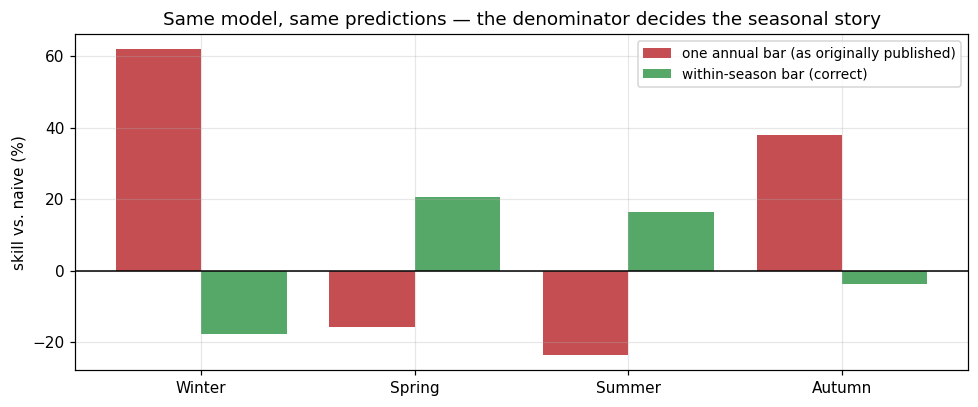

In [20]:
order = ["Winter", "Spring", "Summer", "Autumn"]
plot = seasons.set_index("value").loc[order]

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(order))
ax.bar(x - 0.2, 100 * plot.skill_vs_pooled_naive, 0.4,
       color="#c44e52", label="one annual bar (as originally published)")
ax.bar(x + 0.2, 100 * plot.skill_vs_naive, 0.4,
       color="#55a868", label="within-season bar (correct)")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x, order)
ax.set(ylabel="skill vs. naive (%)",
       title="Same model, same predictions — the denominator decides the seasonal story")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Both headline seasonal claims reverse.** Same model, same predictions, same rows — only
the denominator changes, and predicting zero is the best naive rule in every season, so no
rule swapped in:

| Season | MAE | Within-season naive | One annual bar (as published) | Within-season bar |
|---|---|---|---|---|
| Winter | 0.745 | 0.634 | **+62.0%** | **−17.5%** |
| Autumn | 1.213 | 1.169 | +38.1% | −3.8% |
| Spring | 2.266 | 2.859 | −15.6% | **+20.7%** |
| Summer | 2.421 | 2.895 | **−23.5%** | **+16.4%** |

- **Winter is the model's worst season, not its best.** In dormancy the weight series is a
  slow monotone drain and predicting zero is hard to beat (winter naive MAE 0.634 kg
  against an annual 1.960); the +62% was a bar summer's variance had made three times
  easier to clear.
- **Summer is the model's best season, not a failure** (+16.4% against a summer-specific
  competitor); the −23.5% divided the same predictions by a bar winter's quiet had made
  hard.

This inverts the practical reading: the nectar flow is when a beekeeper would actually
consult a forecast, and it is where the model adds most over what they could already guess.
Section 7 is written from the corrected column, and `Milestone_4.ipynb` §6 and §7.2 carry
the same defect at daily grain.

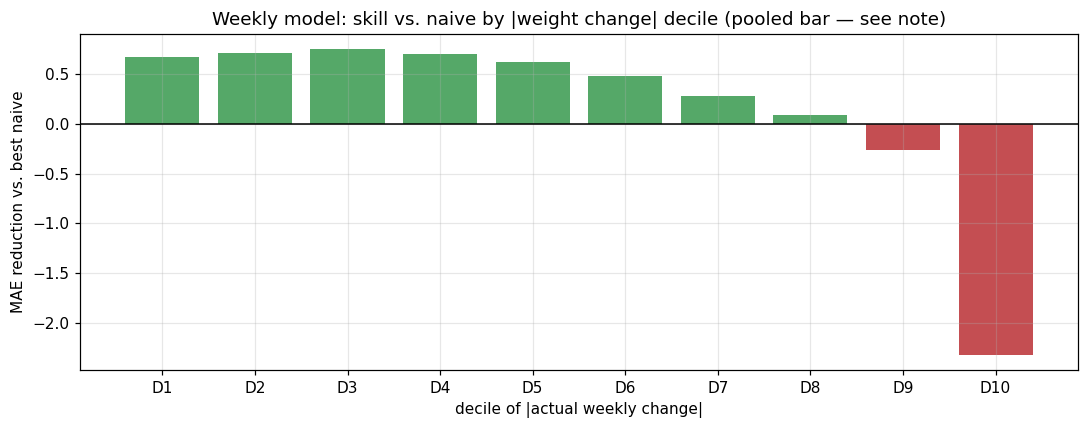

,value,mae,n,baseline_rule,skill_vs_pooled_naive,skill_vs_naive
4,D1,0.6410,210,predict_zero,0.6730,-15.0026
6,D2,0.5554,210,predict_zero,0.7167,-2.9824
7,D3,0.4915,209,predict_zero,0.7493,-1.0482
8,D4,0.5829,210,predict_zero,0.7026,-0.6856
9,D5,0.7472,210,predict_zero,0.6188,-0.5014
10,D6,1.0209,209,predict_zero,0.4792,-0.3754
11,D7,1.4107,210,train_mean,0.2803,-0.2727
12,D8,1.7866,209,month_climatology,0.0885,0.0316
13,D9,2.4673,210,month_climatology,-0.2588,0.2581
5,D10,6.5156,210,persistence,-2.3240,0.2397


In [21]:
decile = segmented[segmented.segment == "weight_change_decile"].copy()
decile["order"] = decile.value.str.lstrip("D").astype(int)
decile = decile.sort_values("order")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(decile.value, decile.skill_vs_pooled_naive,
       color=["#55a868" if s > 0 else "#c44e52" for s in decile.skill_vs_pooled_naive])
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Weekly model: skill vs. naive by |weight change| decile (pooled bar — see note)",
       xlabel="decile of |actual weekly change|", ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()
display(decile[["value", "mae", "n", "baseline_rule",
                "skill_vs_pooled_naive", "skill_vs_naive"]].round(4))

**The decile view keeps the pooled bar, and the reason is the point of the whole
correction.** A |change| decile is defined by the label: predicting zero inside D1 scores
MAE 0.04 kg *because D1 is the set of weeks where almost nothing happened*, so the naive
rule is handed the answer by the segment definition — which is why `skill_vs_naive` reads
−1500% there. That column is printed above only to show why it cannot be read.

On the pooled bar the decile story is unchanged: skill is positive on D1–D7, near zero on
D8, negative on D9–D10 and worst on the largest (−232%). **This model beats its baseline by
being right about weeks where very little happens, and the gains a beekeeper cares about
are in D9 and D10.**

Seasonal and decile are therefore different findings, which the first version ran together.
"Worst where it matters" was always true of the deciles, never of the seasons.

### 6.2 Head-to-head with the daily pipeline

,grain,framing,mae,r2,skill_vs_naive,n_rows,source
0,day,best single-stage (HistGB),0.5420,0.0360,-0.0600,26215,Milestone_4.ipynb 5.1
1,day,"two-stage, hard gate",0.4790,0.0440,0.0590,26215,Milestone_4.ipynb 5.3
2,week,best single-stage (history / RF),1.7020,0.1445,0.0866,3012,this notebook 5.1
3,week,"two-stage, hard gate",1.6296,0.2208,0.1516,3012,this notebook 5.3
4,month,best single-stage (history+sensors+events+hive...,4.3130,0.2812,0.1229,622,this notebook 5.2


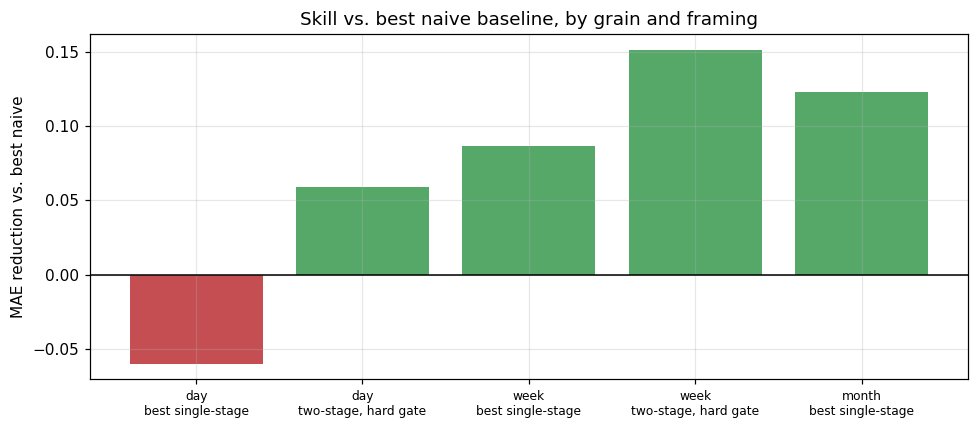

In [22]:
best_week = ev.fold_summary(week_board).iloc[0]
best_month = ev.fold_summary(month_board).iloc[0]
two_stage_week = framings[framings.framing == "two-stage, hard gate"]

comparison = pd.DataFrame([
    {"grain": "day",   "framing": "best single-stage (HistGB)", "mae": 0.542, "r2": 0.036,
     "skill_vs_naive": -0.060, "n_rows": 26215, "source": "Milestone_4.ipynb 5.1"},
    {"grain": "day",   "framing": "two-stage, hard gate",       "mae": 0.479, "r2": 0.044,
     "skill_vs_naive": 0.059,  "n_rows": 26215, "source": "Milestone_4.ipynb 5.3"},
    {"grain": "week",  "framing": f"best single-stage ({best_week.model})",
     "mae": best_week.mae_mean, "r2": best_week.r2_mean, "skill_vs_naive": best_week.skill_mean,
     "n_rows": len(week_df), "source": "this notebook 5.1"},
    {"grain": "week",  "framing": "two-stage, hard gate",       "mae": two_stage_week.mae.mean(),
     "r2": two_stage_week.r2.mean(), "skill_vs_naive": two_stage_week.skill_vs_naive.mean(),
     "n_rows": len(week_df), "source": "this notebook 5.3"},
    {"grain": "month", "framing": f"best single-stage ({best_month.model})",
     "mae": best_month.mae_mean, "r2": best_month.r2_mean, "skill_vs_naive": best_month.skill_mean,
     "n_rows": len(month_df), "source": "this notebook 5.2"},
])
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(comparison)), comparison.skill_vs_naive,
       color=["#55a868" if s > 0 else "#c44e52" for s in comparison.skill_vs_naive])
ax.set_xticks(range(len(comparison)))
ax.set_xticklabels([f"{row.grain}\n{row.framing.split('(')[0].strip()}"
                    for row in comparison.itertuples()], fontsize=8)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Skill vs. best naive baseline, by grain and framing",
       ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()

**Raw MAE is not comparable across grains** — a weekly error of 1.7 kg and a daily error of
0.48 kg measure different quantities, and the weekly target is four times more variable to
begin with. Skill is the comparable column, because each grain is scored against its own
re-derived naive bar. On it the ordering is clear: **week (+15.2% two-stage, +8.7%
single-stage) beats day (+5.9% two-stage, −6.0% single-stage)**, and month is nominally
best on single-stage skill but rests on 622 rows.

## 7. Conclusions and Recommendations

### 7.1 What we can claim

- **Re-graining to a week is the largest improvement in this project so far** — +15.2%
  two-stage skill against +5.9% at daily grain — and **the first grain at which a
  single-stage model beats predicting zero** (+8.7%). The daily negative result was a
  property of the horizon, not of the models.
- **The target's anchor decides the outcome.** Period mean weight rather than last observed
  day flips the result from losing to beating the baseline, at both grains (§2.3).
- **The dominant predictor changes** — yesterday's change at daily grain, the within-week
  OLS slope at weekly, worth roughly 5× the next feature (§5.5).
- **Random Forest beats boosting here**, reversing the daily finding across five seeds with
  non-overlapping ranges, and **the model still generalises to unseen hives** —
  leave-hives-out MAE 1.608 ± 0.125 against a temporal 1.702 (§5.4).
- **The model is at its best during the nectar flow, not dormancy.** Against a within-season
  competitor: Spring +20.7%, Summer +16.4%, Autumn −3.8%, Winter −17.5% (§6.1).
- **Weather does not help, and we now know the ceiling** — +9.1% given a *perfect* forecast
  against +8.7% with none, nothing from current-week weather (§5.6).

### 7.2 What we cannot claim

- **Monthly is underpowered.** +12.3% skill on 433 scored rows from 3.5 years of one
  country's weather, 6–11 observations per feature. Promising; not evidence.
- **The model is still worst on the weeks worth forecasting.** Skill is negative on the top
  two |change| deciles, worst on the largest (−232%), scored against the pooled bar that
  §6.1 argues is right for a label-defined segment.
- **The embargo's value is unmeasured here.** Required for correctness; removing it does not
  inflate the score on this dataset. A fact about these 100 boundary rows, not a general one.
- **Weight change is still not honey yield.** At these grains a harvest lands *inside* the
  forecast window and subtracts 10–20 kg of exactly the quantity predicted.

### 7.3 Attempted next steps — and what came of them

These five were written as recommendations. `Milestone_5.ipynb` carried out four and
substituted a power analysis for the fifth. **Four of the five do not survive being done**,
so the outcomes are recorded here rather than left as open suggestions.

1. **Model gross gain, not net weight change** — *tried; the mechanism is not in the data.*
   The idea was to reconstruct removed mass from a step change coincident with a logged
   harvest. The step changes exist (230 detected removals, 51 hives, median 7.3 kg, 68% in
   May–August); the coincidence does not. Logged `honey` events and sustained weight drops
   agree on **5–10%** in both directions, barely moving as the match window widens from 1
   day to 14, and several logged events coincide with weight *increases* of 30–39 kg — the
   log records that the beekeeper did something about honey, not that honey left. From the
   weight series alone the gross target scores **+1.9%** against net change's +7.6%:
   physically the right quantity, and the harder one. Still the right idea, but it needs an
   event log with removed mass in it — a request to the publishers, not a modelling task.
2. **Give the summer regime its own model** — *tried; no gain, and the target was a
   mirage.* Three gating schemes, all below pooled (+6.7%, +5.2%, +5.1% against +7.6%),
   consistently across folds. The failure mode it attacked — "−24% in summer" — is the
   scoring artifact corrected in §6.1. Summer was never the problem.
3. **Add weather** — *done; see §5.6.* The data layer is built and committed. It is the only
   one of the five that produced a gain, and the gain is an upper bound of half a point,
   which is not worth a forecast integration.
4. **Make the extreme threshold per-hive relative** — *tried; it is worse.* The comparison
   that motivated it was not a comparison: PR-AUC is bounded below by the positive rate, and
   the 5-MAD rule fires on 12.95% of weeks against the absolute rule's 3.05%. Matched to the
   same rate, the absolute label reaches **PR-AUC 0.32 and the relative label 0.20**, and
   end-to-end two-stage regression scores +5.9% against −1.9%. Removing the hive-size
   shortcut makes the label more meaningful and the task less learnable; whether that trade
   is worth making depends on what the alert is for. "Should probably replace" is not
   supported.
5. **More years before trusting the monthly result** — *cannot be done; the archive ends
   2022-12-30.* Substituted a hive-subsampling power curve: ~480 monthly rows are needed
   against the 622 available, so on sampling variability alone the monthly figure clears
   zero — but the curve is not monotone, and a study drawing 40% of this fleet would have
   concluded "no skill" half the time. **More hives are not the binding constraint.** Every
   subsample sees the same three summers, so hive resampling cannot measure what actually
   binds, which is independent *seasons*.

**The one item that came out of doing these**, not on the list above: re-score every
segmented table in `Milestone_4.ipynb` against within-segment baselines, as §6.1 does here.
The daily notebook's "+51% autumn / +34% winter / −95% summer" carries the same defect, and
its §7.2 advice to beekeepers is derived from it.

## Appendix A — Anatomy of one weekly row

In [23]:
full_weeks = week_df[week_df.days_observed == 7].reset_index(drop=True)
example = full_weeks.iloc[[len(full_weeks) // 2]].T
example.columns = ["value"]
display(example.head(45))

schema = pd.DataFrame({"column": week_df.columns, "dtype": [str(t) for t in week_df.dtypes]})
schema["forbidden_as_feature"] = schema.column.isin(pr.PERIOD_FORBIDDEN)
schema["in_history_rung"] = schema.column.isin(pr.PERIOD_FEATURE_SETS["history"])
display(schema)

,value
hive_id,90
period_index,2641
days_observed,7
period_start_date,2020-08-03 00:00:00
period_end_date,2020-08-09 00:00:00
period_last_weight_kg,33.925979
period_first_weight_kg,34.768276
period_mean_weight_kg,35.049131
period_max_weight_kg,36.629583
period_min_weight_kg,33.925979


,column,dtype,forbidden_as_feature,in_history_rung
0,hive_id,int32,False,False
1,period_index,int64,False,False
2,days_observed,int64,False,True
3,period_start_date,datetime64[ns],False,False
4,period_end_date,datetime64[ns],False,False
...,...,...,...,...
97,next_wx_wind_speed_10m_max_mean,float64,False,False
98,next_wx_wind_speed_10m_max_max,float64,False,False
99,next_wx_et0_fao_evapotranspiration_sum,float64,False,False
100,next_wx_growing_degree_days_10c_sum,float64,False,False


## Appendix B — Designs considered and not taken

**Iterated multi-step forecasting.** Keep the daily model and roll it forward seven times,
feeding each prediction back as the next day's input. Legitimate, and it preserves the full
26,215-row training set. Not pursued: the daily model does not beat predicting zero at
step 1, so errors compound from a base already worse than a constant, and the recursion
needs the whole feature vector predicted forward — one modelling problem becomes eight.

**Fixed-endpoint cumulative forecasting.** The question a beekeeper actually asks is not
"how much next week" but "how much by the August harvest" — a shrinking-horizon problem
needing its own target, its own baselines (climatology-to-date is strong), a horizon
feature, and metrics per weeks-remaining, since a 12-week-out and a 1-week-out forecast are
not the same task. Most direct beekeeper value, and the natural sequel.

**Per-hive relative targets.** Dividing the change by the hive's own scale would make a
nucleus and a production hive comparable and fix the absolute-threshold problem in one
move, but it changes what MAE means and breaks comparability with every number in
`Milestone_4.ipynb`, so it belongs in a milestone that can re-baseline everything.

## Appendix C — Reproduction checklist

| Check | Where |
|---|---|
| Clean-checkout run, no network, no credentials | this notebook |
| Row-count waterfall for the re-grain | §2.2 |
| The anchor choice measured, not assumed | §2.3 |
| No leakage — forbidden period columns rejected, with a negative test | §2.4 |
| Extreme threshold re-derived in sd units, not carried over | §3.2 |
| Embargo at every split boundary, with its cost measured | §4.1 |
| Split integrity asserted on label dates, every fold | §4.2 |
| Baselines re-set for the new grain, including climatology | §4.3 |
| Skill score against the best naive, every model, every fold | §§5.1, 5.2 |
| Two-stage honesty — oracle numbers labelled UPPER BOUND | §5.3 |
| Cross-validation — rolling-origin and leave-hives-out, mean ± sd | §§4.2, 5.4 |
| Seed stability before any ranking claim | §5.4 |
| Weather look-ahead forbidden in code, whitelisted only with an explicit `allow=` | §5.6 |
| Weather ablation separates "does weather help" from "do 16 columns fit" | §5.6 |
| Segmented tables — season and \|change\| decile, pooled out-of-fold, each scored against a **within-segment** bar with the pooled convention alongside | §6.1 |
| Label-defined segments (\|change\| decile) explicitly kept on the pooled bar, with the reason | §6.1 |
| Comparison to the daily pipeline on the one comparable metric | §6.2 |
| Every §7.3 recommendation carries the outcome of having done it | §7.3 |